<a href="https://colab.research.google.com/github/meheramey/part-2-cnn-computer-vision-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Computer Vision Problem Formulation and CNN Prototype
**Dataset:** Synthetic Manufacturing Defect Image Dataset  
**Goal:** Classify product surface images into 4 categories: normal, scratch, dent, stain  
**Dataset Source:** BITSoM Module 5 - Part 2

---
## Task 1: Problem Identification

### Problem Type: Image Classification

**Why Image Classification?**
- Each image belongs to **one of 4 fixed categories**: normal, scratch, dent, stain
- There are no bounding boxes or pixel-level masks required
- The task is to assign a single class label to each entire image
- This is a **multi-class classification** problem (4 classes)

**Why NOT other types?**
- Object Detection: Would require bounding boxes around defects — not needed here
- Semantic Segmentation: Would require pixel-level labeling — overkill for this task
- Instance Segmentation: Requires both bounding boxes + pixel masks — not applicable

**Real-world Application:** Automated quality inspection on a manufacturing production line

In [47]:
# Create results folders
import os
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)
print('Folders ready!')

Folders ready!


In [48]:
import os
import shutil

# Create folder structure
os.makedirs('./images/normal', exist_ok=True)
os.makedirs('./images/scratch', exist_ok=True)
os.makedirs('./images/stain', exist_ok=True)
os.makedirs('./images/dent', exist_ok=True)

# Move files based on their name prefix
for f in os.listdir('.'):
    if f.endswith('.png'):
        if f.startswith('normal'):
            shutil.move(f, f'./images/normal/{f}')
        elif f.startswith('scratch'):
            shutil.move(f, f'./images/scratch/{f}')
        elif f.startswith('stain'):
            shutil.move(f, f'./images/stain/{f}')
        elif f.startswith('dent'):
            shutil.move(f, f'./images/dent/{f}')

# Verify
for folder in ['normal', 'scratch', 'stain', 'dent']:
    count = len(os.listdir(f'./images/{folder}'))
    print(f'{folder}: {count} images')

normal: 120 images
scratch: 120 images
stain: 120 images
dent: 120 images


In [49]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully!')

TensorFlow version: 2.20.0
All libraries imported successfully!


---
## Task 2: Dataset Exploration

In [50]:
# Load labels.csv
labels_df = pd.read_csv('labels.csv')
print('=== DATASET OVERVIEW ===')
print(f'Total Images: {len(labels_df)}')
print(f'Columns: {list(labels_df.columns)}')
print()
print('=== CLASS DISTRIBUTION ===')
class_counts = labels_df['class'].value_counts()
print(class_counts)
print(f'\nNumber of Classes: {labels_df["class"].nunique()}')
print(f'Classes: {list(labels_df["class"].unique())}')

=== DATASET OVERVIEW ===
Total Images: 480
Columns: ['filename', 'class']

=== CLASS DISTRIBUTION ===
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Number of Classes: 4
Classes: ['normal', 'scratch', 'dent', 'stain']


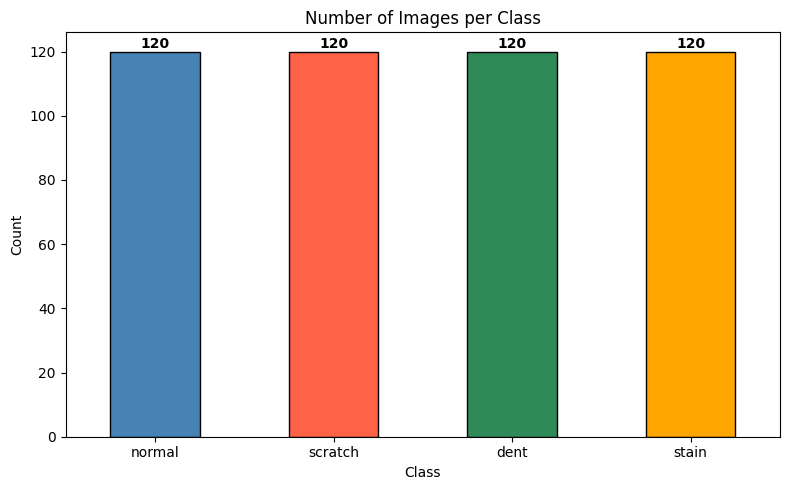

Class distribution is balanced - 120 images per class!


In [51]:
# Class Distribution Plot
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['steelblue','tomato','seagreen','orange'], edgecolor='black')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution is balanced - 120 images per class!')

In [52]:
# Check Image Dimensions
sample_img = load_img(labels_df['filename'][0])
print(f'=== IMAGE DIMENSIONS ===')
print(f'Sample image path: {labels_df["filename"][0]}')
print(f'Original size: {sample_img.size} (width x height)')
print(f'Mode: {sample_img.mode}')
arr = img_to_array(sample_img)
print(f'Array shape: {arr.shape}')

=== IMAGE DIMENSIONS ===
Sample image path: images/normal/normal_001.png
Original size: (96, 96) (width x height)
Mode: RGB
Array shape: (96, 96, 3)


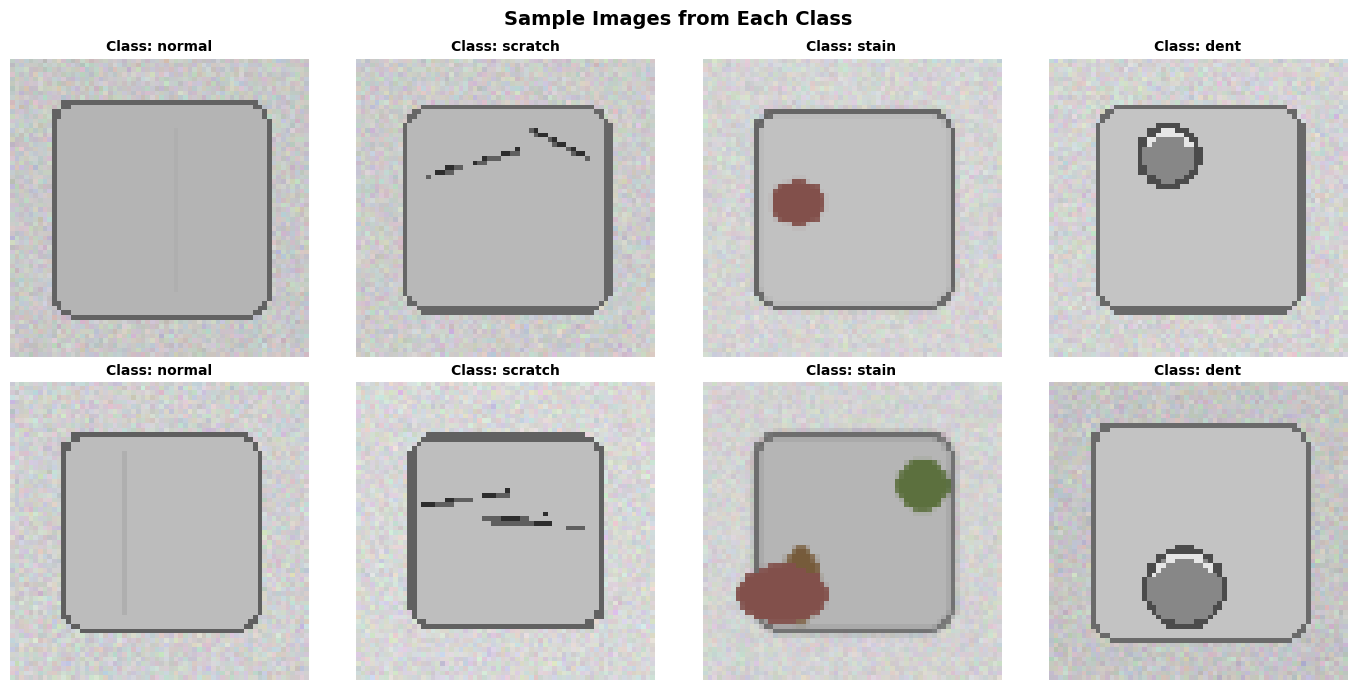

Sample images displayed!


In [53]:
# Show Sample Images from Each Class
classes = ['normal', 'scratch', 'stain', 'dent']
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, cls in enumerate(classes):
    # Get 2 sample images per class
    samples = labels_df[labels_df['class'] == cls]['filename'].values[:2]
    for row, img_path in enumerate(samples):
        img = load_img(img_path, target_size=(64, 64))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'Class: {cls}', fontsize=10, fontweight='bold')
        axes[row][col].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images displayed!')

---
## Task 3: Image Preprocessing

In [54]:
# Image Preprocessing Parameters
IMG_SIZE = (64, 64)   # Resize all images to 64x64
IMG_CHANNELS = 3      # RGB

# Label Encoding
class_map = {'normal': 0, 'scratch': 1, 'stain': 2, 'dent': 3}
print('Class mapping:', class_map)

# Load and preprocess all images
X = []
y = []

print('\nLoading images...')
for _, row in labels_df.iterrows():
    img = load_img(row['filename'], target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = arr / 255.0  # Normalize pixel values to [0, 1]
    X.append(arr)
    y.append(class_map[row['class']])

X = np.array(X)
y = np.array(y)

print(f'X shape: {X.shape}  (samples, height, width, channels)')
print(f'y shape: {y.shape}')
print(f'Pixel value range: [{X.min():.2f}, {X.max():.2f}]')
print('Normalization done!')

Class mapping: {'normal': 0, 'scratch': 1, 'stain': 2, 'dent': 3}

Loading images...
X shape: (480, 64, 64, 3)  (samples, height, width, channels)
y shape: (480,)
Pixel value range: [0.18, 1.00]
Normalization done!


In [55]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples:  {X_train.shape[0]}')
print(f'Testing samples:   {X_test.shape[0]}')
print(f'Image shape:       {X_train.shape[1:]}')

# Convert labels to one-hot encoding for categorical crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=4)
print('\nOne-hot encoding done!')
print(f'y_train_cat shape: {y_train_cat.shape}')

Training samples:  384
Testing samples:   96
Image shape:       (64, 64, 3)

One-hot encoding done!
y_train_cat shape: (384, 4)


---
## Task 4: CNN Model Creation

In [56]:
# Build CNN Model
tf.random.set_seed(42)

model = keras.Sequential([
    # Input
    layers.Input(shape=(64, 64, 3)),

    # Block 1: Convolution + ReLU + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Convolution + ReLU + Pooling
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: Convolution + ReLU + Pooling
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    # Output Layer - Softmax for multi-class classification
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,468 (4.36 MB)

 Trainable params: 1,142,468 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 5: Model Training and Evaluation

In [57]:
# Train the CNN
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print('\nTraining complete!')

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 348ms/step - accuracy: 0.2606 - loss: 1.4653 - val_accuracy: 0.2338 - val_loss: 1.3936
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.2248 - loss: 1.3929 - val_accuracy: 0.2208 - val_loss: 1.3877
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.2410 - loss: 1.3847 - val_accuracy: 0.2208 - val_loss: 1.3876
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.2704 - loss: 1.3838 - val_accuracy: 0.3766 - val_loss: 1.3865
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.2769 - loss: 1.3816 - val_accuracy: 0.2208 - val_loss: 1.3746
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.3257 - loss: 1.3571 - val_accuracy: 0.4805 - val_loss: 1.2913
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.4007 - loss: 1.2826 - val_accuracy: 0.7273 - val_loss: 1.0123
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.5700 - loss: 1.0109 - val_accuracy: 0.

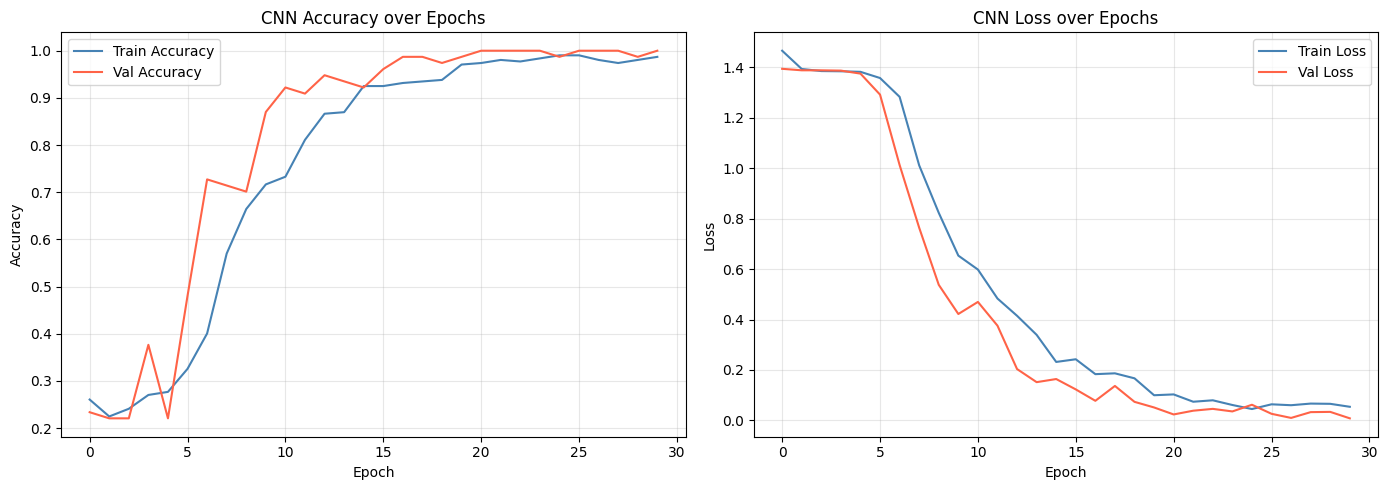

Accuracy/Loss curves saved!


In [58]:
# Training vs Validation Accuracy/Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Accuracy/Loss curves saved!')

In [59]:
# Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)

print('=== MODEL PERFORMANCE ===')
print(f'Training Accuracy:   {train_acc*100:.2f}%')
print(f'Training Loss:       {train_loss:.4f}')
print(f'Testing Accuracy:    {test_acc*100:.2f}%')
print(f'Testing Loss:        {test_loss:.4f}')

=== MODEL PERFORMANCE ===
Training Accuracy:   99.74%
Training Loss:       0.0149
Testing Accuracy:    97.92%
Testing Loss:        0.0513


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


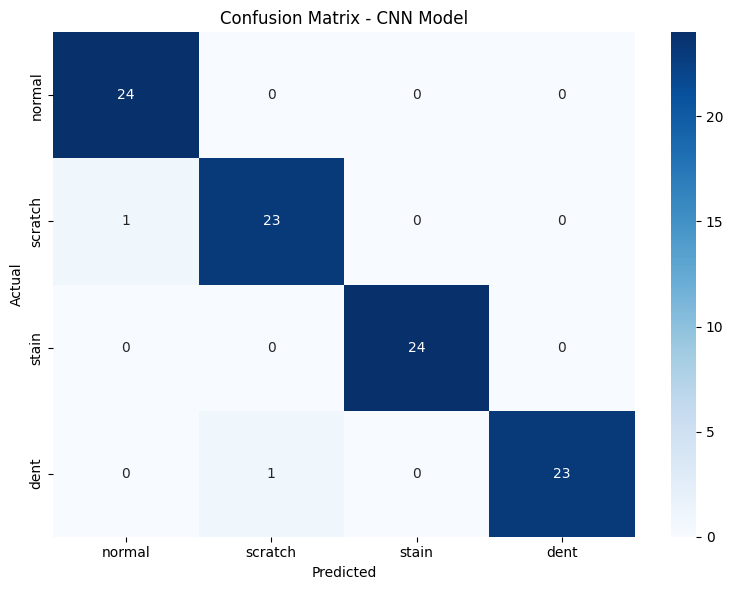


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        24
     scratch       0.96      0.96      0.96        24
       stain       1.00      1.00      1.00        24
        dent       1.00      0.96      0.98        24

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



In [60]:
# Confusion Matrix
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
class_names = ['normal', 'scratch', 'stain', 'dent']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - CNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=class_names))

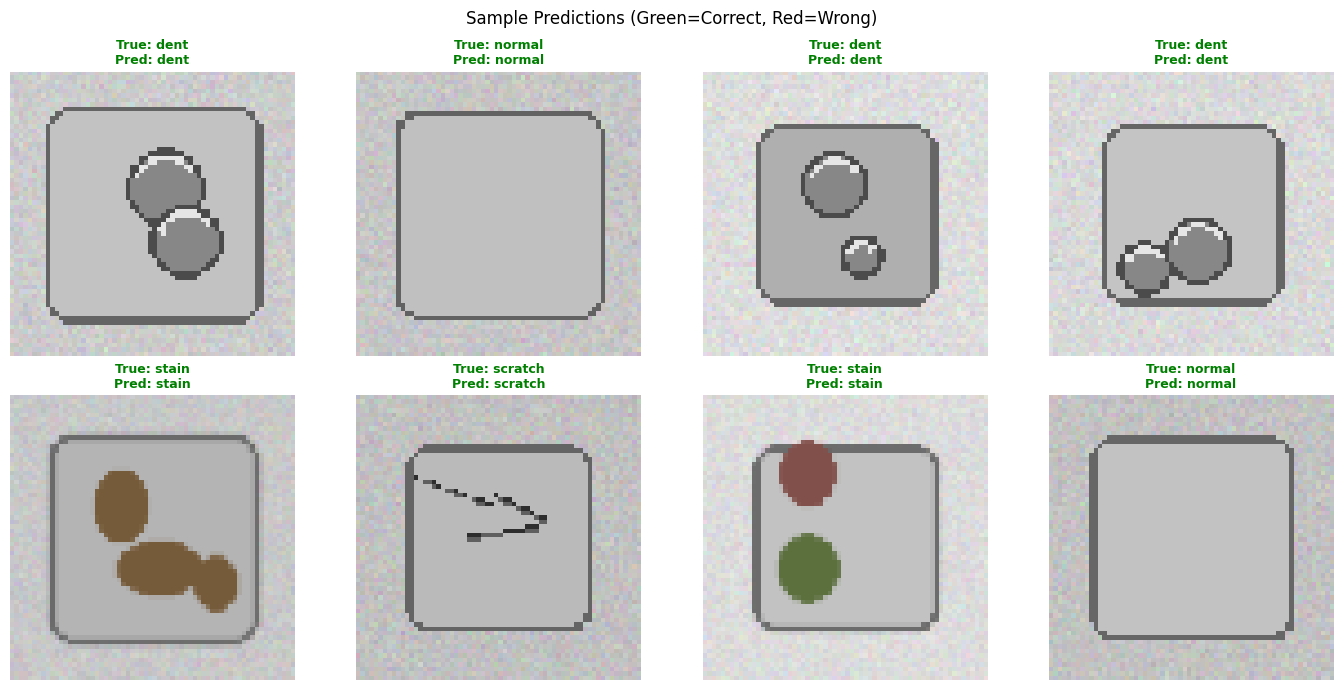

Sample predictions saved!


In [61]:
# Sample Predictions on Test Images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
indices = np.random.choice(len(X_test), 8, replace=False)

for idx, ax in zip(indices, axes.flatten()):
    ax.imshow(X_test[idx])
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions saved!')

---
## Task 6: CNN Concept Explanation

### What is Convolution?
Convolution is the core operation in a CNN. A small filter (e.g., 3x3 matrix) slides over the entire image and performs element-wise multiplication with the pixels underneath, then sums them up into a single value. This creates a **feature map** that captures specific patterns like edges, textures, or shapes. Different filters detect different features — some detect horizontal edges, some detect vertical edges, etc.

### Why is Pooling Used?
Pooling (e.g., MaxPooling 2x2) reduces the spatial size of feature maps by keeping only the most important value in each region. It serves two purposes:
1. **Reduces computation** — smaller feature maps = fewer parameters
2. **Makes model robust** — slight shifts or rotations in the image don't affect the output
MaxPooling keeps the strongest feature activation in each region.

### Why is ReLU Commonly Used in CNNs?
ReLU (Rectified Linear Unit) is `f(x) = max(0, x)`. It is used because:
- It introduces **non-linearity** without vanishing gradient problems
- It is **computationally cheap** (just a threshold at 0)
- It **speeds up training** compared to sigmoid or tanh
- It avoids the vanishing gradient problem that affects deep networks

### Why are CNNs Better than Regular Feed-Forward Networks for Images?
- **Parameter sharing:** Same filter is applied across the entire image — far fewer parameters than a fully connected layer on raw pixels
- **Spatial awareness:** CNNs understand that nearby pixels are related — a regular network treats all pixels independently
- **Translation invariance:** CNNs can recognize patterns regardless of where they appear in the image
- **Hierarchical learning:** Early layers learn edges, middle layers learn shapes, deep layers learn complex objects

---
## Task 7: Business Use Case Mapping

### Domain: Manufacturing

**Business Problem:**  
In a manufacturing plant, products on the assembly line must be inspected for surface defects before shipping. Currently, human inspectors visually check each product — this is slow, expensive, and prone to human error especially during long shifts.

**AI Solution:**  
Deploy a CNN-based image classification system with cameras on the production line. Each product image is captured and automatically classified as:
- `normal` → Pass, send to packaging
- `scratch` / `dent` / `stain` → Fail, route to rework or rejection

**Business Benefits:**
- **Speed:** Inspect thousands of products per hour automatically
- **Consistency:** No fatigue — same accuracy at all hours
- **Cost Reduction:** Fewer human inspectors needed
- **Quality Improvement:** Fewer defective products reach customers
- **Data Insights:** Track which defect types are most common to improve production process

**Other Possible Domains:**
- **Healthcare:** Classify medical images (X-rays, skin lesions) for disease detection
- **Agriculture:** Detect crop diseases from drone images
- **Retail:** Identify damaged products in warehouses